In [1]:
channel_name = 'Britec09'

In [3]:
import pandas as pd
from datetime import datetime, timedelta
from googleapiclient.discovery import build
import os
import re
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
# Load environment variables from .env file
load_dotenv()

# Retrieve API key from environment variables
YOUTUBE_DEVELOPER_KEY = os.getenv('YOUTUBE_DEVELOPER_KEY')

# Verify API key is loaded
if not YOUTUBE_DEVELOPER_KEY:
    raise ValueError("YouTube API key not found. Please create a .env file with YOUTUBE_API_KEY=")
    
youtube = build('youtube', 'v3', developerKey=YOUTUBE_DEVELOPER_KEY)

In [5]:
def get_channel(channel_name):
    return youtube.search().list(q=channel_name, type='channel', part='id,snippet').execute()['items'][0]

channel_id = get_channel(channel_name)['id']['channelId']
channel_id

'UC_M-iWYpQbgo4rK1YfewI5w'

# Diving into YouTube Analytics
Deepnote presented a live stream featuring a showcase of how to use Google's YouTube API. We had a few Deepnote coders and a Deepnote user Allan who helped crack the API and start getting data. Below is a project inspired from that stream!

In this notebook we are going to dive in and check out the popular YouTube channel Good Mythical Morning.

## API Functions
In this section we setup some API functions to help us gather data. We create a function to gather channel stats and video stats. To do this in a effecient way and save API calls we do not use the search function. We pull in GMM's upload playlist ( containing all of their videos ) and use that to build a video list. Then grab the data from each video.

In [9]:
# Function to get the channels stats
# It will also contain the upload playlist ID we can use to grab videos.
def get_channel_stats(youtube, channel_id):
    request = youtube.channels().list(
        part="snippet,contentDetails,statistics",
        id=channel_id
    )
    response = request.execute()
    
    return response['items']

In [11]:
# This will get us a list of videos from a playlist.
# Note a page of results has a max value of 50 so we will
# need to loop over our results with a pageToken

def get_video_list(youtube, upload_id):
    video_list = []
    request = youtube.playlistItems().list(
        part="snippet,contentDetails",
        playlistId=upload_id,
        maxResults=50
    )
    next_page = True
    while next_page:
        response = request.execute()
        data = response['items']

        for video in data:
            video_id = video['contentDetails']['videoId']
            if video_id not in video_list:
                video_list.append(video_id)

        # Do we have more pages?
        if 'nextPageToken' in response.keys():
            next_page = True
            request = youtube.playlistItems().list(
                part="snippet,contentDetails",
                playlistId=upload_id,
                pageToken=response['nextPageToken'],
                maxResults=50
            )
        else:
            next_page = False

    return video_list

In [13]:
# new function
def get_video_details(youtube, video_list):
    stats_list = []

    # Can only get 50 videos at a time.
    for i in range(0, len(video_list), 50):
        request = youtube.videos().list(
            part="snippet,contentDetails,statistics",
            id=video_list[i:i+50]
        )

        data = request.execute()
        for video in data['items']:
            video_id = video['id']  # Extract video_id 
            title = video['snippet']['title']
            published = video['snippet']['publishedAt']
            description = video['snippet']['description']
            view_count = video['statistics'].get('viewCount', 0)
            like_count = video['statistics'].get('likeCount', 0)
            dislike_count = video['statistics'].get('dislikeCount', 0)
            comment_count = video['statistics'].get('commentCount', 0)
            duration = video['contentDetails'].get('duration', 'Unknown')  # Use .get() with a default value

            # Include video_id in the dictionary
            stats_dict = dict(
                video_id=video_id,
                title=title,
                description=description,
                published=published,
                view_count=view_count,
                like_count=like_count,
                dislike_count=dislike_count,
                comment_count=comment_count,
                duration=duration             
            )
            stats_list.append(stats_dict)

    return stats_list

In [15]:
def convert_iso_duration_to_hms(duration):
    """
    Converts an ISO 8601 duration string (e.g., 'PT3M54S') to 'H:M:S' format.
    
    Args:
        duration (str): The ISO 8601 duration string (e.g., 'PT3M54S').
    
    Returns:
        str: The duration in 'H:M:S' format.
    """
    # Regex to extract hours, minutes, and seconds from the ISO 8601 duration
    pattern = re.compile(r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?')
    match = pattern.match(duration)
    
    if not match:
        return "0:00:00"  # Default if the format is invalid
    
    # Extract hours, minutes, and seconds
    hours = int(match.group(1)) if match.group(1) else 0
    minutes = int(match.group(2)) if match.group(2) else 0
    seconds = int(match.group(3)) if match.group(3) else 0
    
    # Create a timedelta object
    delta = timedelta(hours=hours, minutes=minutes, seconds=seconds)
    
    # Convert to total seconds
    total_seconds = int(delta.total_seconds())
    
    # Convert total seconds to H:M:S format
    hours = total_seconds // 3600
    minutes = (total_seconds % 3600) // 60
    seconds = total_seconds % 60
    
    return f"{hours}:{minutes:02d}:{seconds:02d}"

## Create our Channel Stats

In [18]:
channel_stats = get_channel_stats(youtube, channel_id)

## Find our Upload Playlist ( will contain all video uploads )

In [21]:
upload_id = channel_stats[0]['contentDetails']['relatedPlaylists']['uploads']
upload_id

'UU_M-iWYpQbgo4rK1YfewI5w'

## Get our Video List

In [24]:
video_list = get_video_list(youtube, upload_id)

## Get our Video Details
Finally we will get all of our videos details returned in a dictionary.

In [27]:
video_data = get_video_details(youtube, video_list)
'Number 0f Videos: ' + str(len(video_data))

'Number 0f Videos: 3979'

## Pause and think what to do next

In [30]:
df=pd.DataFrame(video_data)
df.shape

(3979, 9)

In [32]:
df['title_length'] = df['title'].str.len()
df["view_count"] = pd.to_numeric(df["view_count"])
df["like_count"] = pd.to_numeric(df["like_count"])
df["dislike_count"] = pd.to_numeric(df["dislike_count"])
df["comment_count"] = pd.to_numeric(df["comment_count"])
df["published"] = pd.to_datetime(df["published"])
# Format the 'published' column to "%Y-%m-%d"
df["published"] = df["published"].dt.strftime("%Y-%m-%d")
# reaction used later add up likes + dislikes + comments
df["reactions"] = df["like_count"] + df["dislike_count"] + df["comment_count"] + df["comment_count"]
df['hms_format'] = df['duration'].apply(convert_iso_duration_to_hms)

In [34]:
# Select rows where the title contains "Animation Maker"
#result = df
result = df.query('title.str.lower().str.contains("windows 11")', engine='python')
result.shape

(479, 12)

In [36]:
cols = 'video_id title published view_count title_length hms_format'.split()

In [38]:
# Retrieve the maximum value from the title_length column
max_title_length = result['title_length'].max()
print("Maximum title length:", max_title_length)
# Set pandas column display width to the maximum title_length value
pd.set_option('display.max_colwidth', max_title_length)
result[cols].sort_values(by='published', ascending=False).head(30)

Maximum title length: 81


,video_id,title,published,view_count,title_length,hms_format
1,k-7j97T44Tw,Windows 11 Bloatware: What You NEED To Know (2026),2026-01-10,11154,50,0:26:22
13,UsRb13RVubE,Windows 11 Feature Eating Your System RAM and Slowing Your PC,2025-12-27,37658,61,0:08:10
18,MXfSjlohsoU,Why Are People Not Switching To Windows 11,2025-12-20,53667,42,0:16:13
20,HWacOYaOoX4,Microsoft Adds A Themes Hub To Windows 11,2025-12-18,4561,41,0:05:43
25,uRN_s6QYK8U,Don’t Want AI in Windows 11? Here’s How to Get Rid of It!,2025-12-11,22244,57,0:08:32
29,nphUCnjJc7U,This Windows 11 Install Changes Everything,2025-12-06,22170,42,0:24:16
31,mjMGBg4obhU,Windows 11 Security Feature You Should Use,2025-12-04,10500,42,0:11:12
32,1XhbEWuXQRQ,Do This After Installing Windows 11 LTSC,2025-12-03,7910,40,0:20:44
33,Eok5aHe5fpM,The Windows 11 Everyone Wanted,2025-12-02,18669,30,0:11:16
34,qregLa7ffDI,I Am Done With Windows 11,2025-12-01,31719,25,0:17:32


## Most Viewed Videos

In [41]:
df_highest_views = result.nlargest(10, 'view_count')
df_highest_views['title'] = df_highest_views['title'].str[:94]
df_highest_views['view_count_millions'] = df_highest_views['view_count'] / 5000
df_highest_views[cols]

,video_id,title,published,view_count,title_length,hms_format
1419,u2afU_wgox4,How to Downgrade Windows 11 to Windows 10,2022-04-12,1859270,41,0:11:20
1350,0gOZoroPNuA,How to Reset Windows 11 Password Without Any Software,2022-06-28,1560019,53,0:09:41
1193,mSaWcmrVO3I,Bypass Microsoft Account Sign in While Installing Windows 11,2022-12-26,934377,60,0:00:49
1613,9yHq0xuupbw,How to Download and Update Realtek HD Audio Driver on Windows 10 or Windows 11,2021-08-25,885847,78,0:10:16
1464,IQVNLUdXbHA,5 Ways to Change User Account Name in Windows 11,2022-02-17,831613,48,0:06:20
1665,3BEpt-bpk44,How to Change Taskbar Size in Windows 11,2021-06-24,776850,40,0:03:20
1614,FMumFFcdtec,Fix Windows Security Not Working in Latest Windows 11,2021-08-24,686429,53,0:03:47
1413,GBKe5V26yQs,How to Enter the BIOS / UEFI on Windows 11,2022-04-19,611453,42,0:06:06
1330,v8-ikrGijTs,How to Disable Microsoft Defender Antivirus in Windows 11,2022-07-20,515439,57,0:13:42
1561,A0BS0lb_Amk,How to Make the Windows 11 Taskbar Completely Transparent,2021-10-23,497675,57,0:05:51


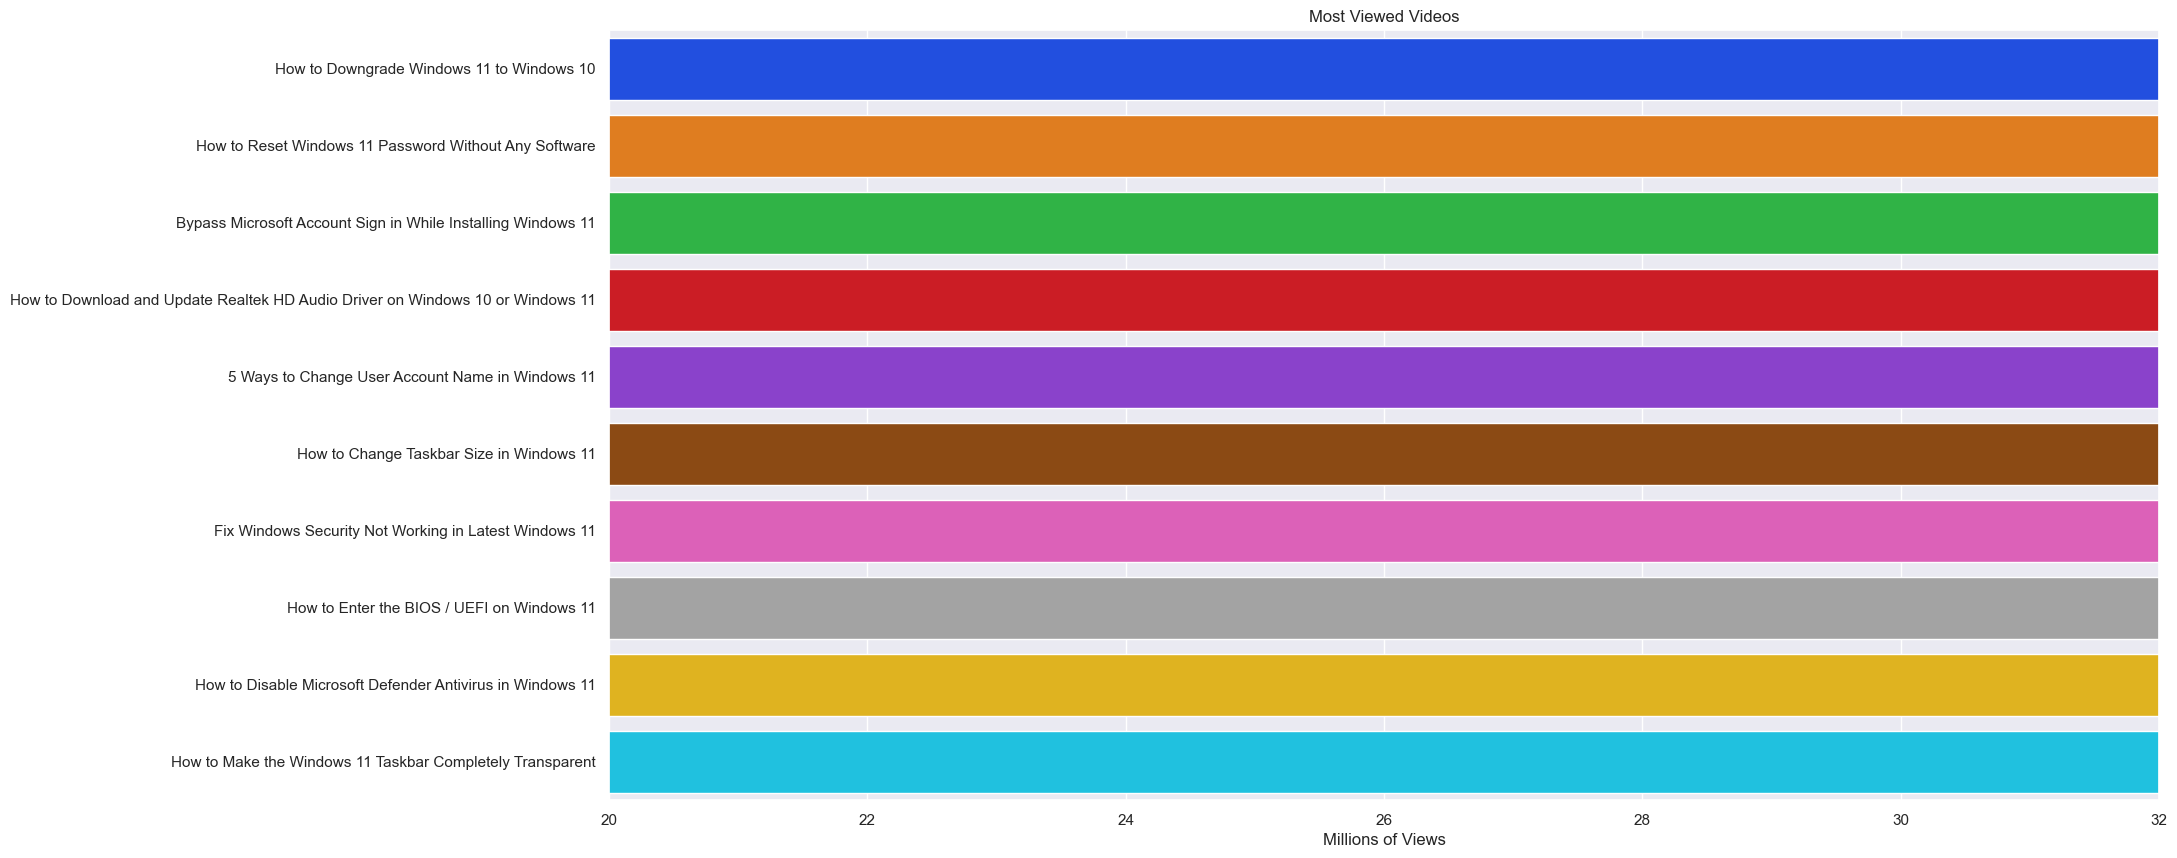

In [43]:
# Set the figure size
sns.set(rc={'figure.figsize': (20, 10)})

# Create the barplot
plot = sns.barplot(
    x="view_count_millions", 
    y="title", 
    hue="title",  # Assign y variable to hue
    data=df_highest_views, 
    palette="bright", 
    legend=False  # Disable the legend
)

# Set labels and title
plot.set(xlabel='Millions of Views', ylabel='')
plot.set_title('Most Viewed Videos')

# Set x-axis limits
plt.xlim(20, 32)

# Show the plot
plt.show()

In [45]:
colt = 'video_id title published view_count hms_format'.split()
output_file = channel_name + '.csv'
result[colt].to_csv(output_file, index=None)
result[colt].sort_values(by="published",ascending=False)

,video_id,title,published,view_count,hms_format
1,k-7j97T44Tw,Windows 11 Bloatware: What You NEED To Know (2026),2026-01-10,11154,0:26:22
13,UsRb13RVubE,Windows 11 Feature Eating Your System RAM and Slowing Your PC,2025-12-27,37658,0:08:10
18,MXfSjlohsoU,Why Are People Not Switching To Windows 11,2025-12-20,53667,0:16:13
20,HWacOYaOoX4,Microsoft Adds A Themes Hub To Windows 11,2025-12-18,4561,0:05:43
25,uRN_s6QYK8U,Don’t Want AI in Windows 11? Here’s How to Get Rid of It!,2025-12-11,22244,0:08:32
...,...,...,...,...,...
1669,4APMzvQZIKE,My Thoughts On Windows 11,2021-06-19,15219,0:10:10
1670,aoFB13iOlcI,Microsoft Clears Way for Windows 11,2021-06-18,27600,0:07:26
1671,tcxAwNcm2lo,How to Switch Back to Windows 10 Start Menu in Windows 11,2021-06-17,130582,0:04:51
1672,NeibenDT0Ho,Windows 11 Leaked Let's Check it Out,2021-06-16,51429,0:11:31


In [47]:
# Get the user's home directory
user_path = os.path.expanduser('~')
# Get the current working directory
current_path = os.getcwd()
# Derive the base directory (base_dir) by removing the last folder ('Daily')
base_path = os.path.dirname(current_path)
#C:\Users\PC1\OneDrive\A5\Excel
xsl_path = os.path.join(base_path, "Excel")

In [49]:
print("User path:", user_path)
print(f"Current path: {current_path}")
print(f"Base path: {base_path}")
print(f"Excel path (xsl_path): {xsl_path}")

User path: C:\Users\PC1
Current path: C:\Users\PC1\OneDrive\A4\YouTube
Base path: C:\Users\PC1\OneDrive\A4
Excel path (xsl_path): C:\Users\PC1\OneDrive\A4\Excel


In [51]:
xsl_file = channel_name + '.xlsx'
xsl_file = os.path.join(xsl_path, xsl_file)
xsl_file

'C:\\Users\\PC1\\OneDrive\\A4\\Excel\\Britec09.xlsx'

In [53]:
colt = 'video_id title published view_count hms_format read'.split()
df_highest_views['read'] = 'N'
df_highest_views[colt].to_excel(xsl_file, index=False)